### 문제 개요 및 과업
- 단층 퍼셉트론으로 해결 불가능한 XOR 문제를 다중 퍼셉트론이 어떻게 해결하는지 이해한다.
- 히든 레이어 를 통과할 때 데이터의 공간 배치 가 어떻게 변하는지 좌표평면에 시각화하여, 비선형 문제가 선형 분리 가능한 문제로 변환되는 과정을 확인한다.

### 문제 정의 XOR 문제의 한계
- XOR 논리 게이트: 입력값이 서로 다를 때만 1(True)을 출력하고, 같으면 0(False)을 출력한다.
- (0,0)과 (1,1)은 0이고, (0,1)과 (1,0)은 1이다. 이 네 점을 좌표평면에 찍으면 어떤 직선 하나로도 0과 1을 완벽하게 가를 수 없다.

### 1. 데이터 정의 
- X (입력값): 2차원 평면상의 점 (x,y) 좌표들입니다.
- y (결과값): 각 점이 속한 정답 클래스(빨강 , 파랑)
### 2. 활성화 함수 정의 
- 시그모이드 함수: 입력값을 0과 1 사이의 값으로 변환합니다. 출력값을 확률로 해석하거나 , 비선형을 추가할떄 사용.
### 3. (w)가중치 ,(b) 바이어스 값 정의
- 현재 2×2 행렬로, 입력 특징 2개를 받아 2개의 노드로 연산

In [10]:
import numpy as np
import matplotlib.pyplot as plt
# 데이터 정의
data = [
    [0.05, 0.05], [0.12, 0.08], [0.08, 0.15], # Class 0
    [0.05, 0.92], [0.15, 0.88], [0.10, 0.80], # Class 1
    [0.92, 0.12], [0.85, 0.05], [0.80, 0.15], # Class 1
    [0.95, 0.95], [0.88, 0.82], [0.82, 0.88]  # Class 0
]
X = np.array(data)
y = np.array([0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0])

# 가중치 및 바이어스 값 설정
W1 = np.array([[-2.0, 2.0], [-2.0, 2.0]])
b1 = np.array([3.0, -1.0])

# 시그모이드 함수 적용
hidden_output = sigmoid(np.dot(X, W1) + b1)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

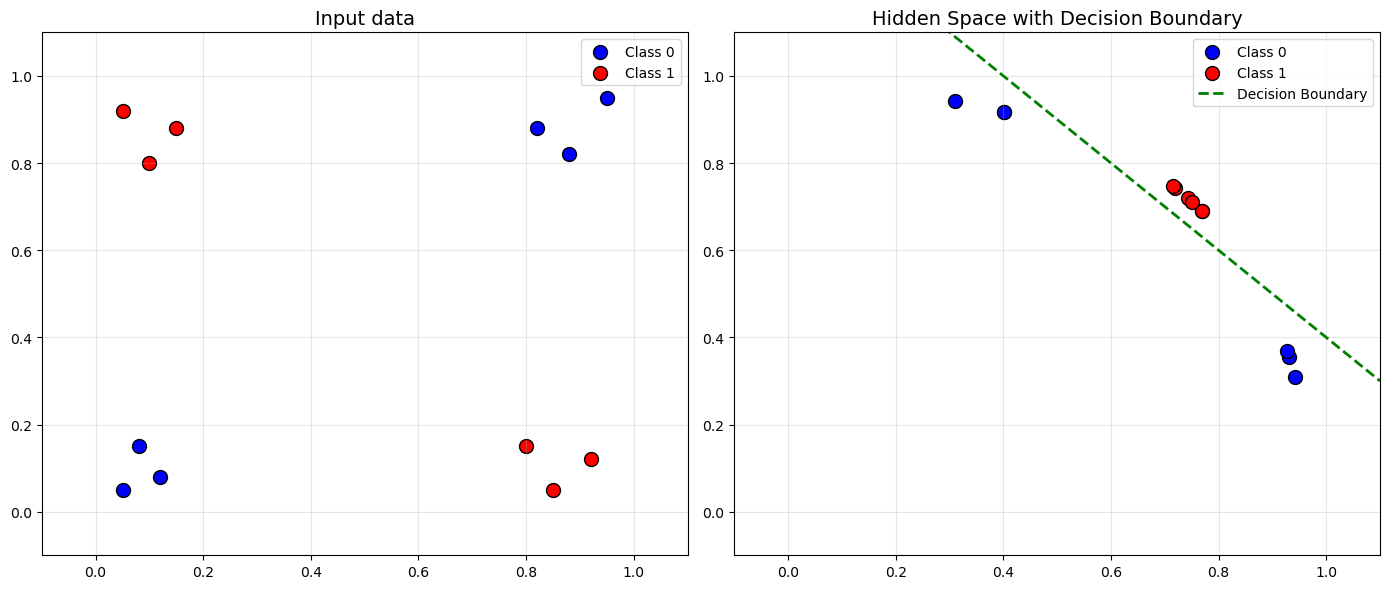

In [15]:
# 그래프 1 -> 기존 데이터의 분포도
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', s=100, label='Class 0', edgecolors='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', s=100, label='Class 1', edgecolors='k')
plt.title("Input data", fontsize=14)
plt.xlim(-0.1, 1.1); plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()

# 그래프 2 -> 히든 레이어(시그모이드 함수) 적용후
plt.subplot(1, 2, 2)
plt.scatter(hidden_output[y==0, 0], hidden_output[y==0, 1], c='blue', s=100, label='Class 0', edgecolors='k')
plt.scatter(hidden_output[y==1, 0], hidden_output[y==1, 1], c='red', s=100, label='Class 1', edgecolors='k')

h1_range = np.linspace(-0.1, 1.1, 10)
h2_boundary = -1.0 * h1_range + 1.4 
plt.plot(h1_range, h2_boundary, color='green', linestyle='--', linewidth=2, label='Decision Boundary')

plt.title("Hidden Space with Decision Boundary", fontsize=14)
plt.xlim(-0.1, 1.1); plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()